# Notebook 2.1 — Precompute Phase 1 Signals

**Purpose:** Run Phase 1 inference on every historical row (2010->present) ONCE and cache results.  
**Output:** `data/enriched_rl_data.csv` with `Phase1_Signal` column.

### Why pre-compute?
RL needs ~1M environment steps to learn. Running PyTorch LSTM per step = 13+ hours.  
Pre-computing reduces RL step time from ~50ms to microseconds.

### Sentiment Strategy
`universal_sentiment_history.pkl` contains FinBERT-scored financial news (US stocks, 2010–2020).  
We compute the **mean daily_score across all stocks per date** as a market-wide sentiment proxy.  
Timeline gaps are filled using linear interpolation. Dates outside the pre-computed range (e.g. post-2020) are wrapped back into the active PKL date range by applying a 6-year offset, preserving weekdays and seasonality. This ensures 100% sentiment coverage.


In [8]:
# CELL 1: IMPORTS
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import joblib
from tqdm.notebook import tqdm

print("Cell 1 done: imports loaded.")
print("PyTorch:", torch.__version__, "| Pandas:", pd.__version__)


Cell 1 done: imports loaded.
PyTorch: 2.12.1+cpu | Pandas: 2.3.3


In [9]:
# CELL 2: CONFIGURATION & GLOBALS
TARGET_TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "NVDA"]
START_DATE     = "2010-01-01"
SEQ_LENGTH     = 60  # Must match Phase 1 training

POSSIBLE_ARTIFACT_PATHS = ["../model_artifacts", "model_artifacts", "GenWealth/model_artifacts"]
ARTIFACTS_DIR = None
for p in POSSIBLE_ARTIFACT_PATHS:
    if os.path.exists(p) and os.path.exists(p + "/production_lstm.pth"):
        ARTIFACTS_DIR = p
        break
if ARTIFACTS_DIR is None:
    raise FileNotFoundError("CRITICAL: Cannot find model_artifacts directory with production_lstm.pth")

SENTIMENT_PKL_PATH = os.path.join(ARTIFACTS_DIR, "universal_sentiment_history.pkl")
OUTPUT_DIR  = "../data" if os.path.basename(os.getcwd()) == "notebooks" else "data"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "enriched_rl_data.csv")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Cell 2 done: Configuration loaded.")
print("  Target Tickers :", TARGET_TICKERS)
print("  Artifacts Dir  :", os.path.abspath(ARTIFACTS_DIR))
print("  Sentiment PKL  :", os.path.abspath(SENTIMENT_PKL_PATH))
print("  Output Path    :", os.path.abspath(OUTPUT_PATH))
print("  Device         :", DEVICE)


Cell 2 done: Configuration loaded.
  Target Tickers : ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'NVDA']
  Artifacts Dir  : d:\Study\Projects\GenWealth\model_artifacts
  Sentiment PKL  : d:\Study\Projects\GenWealth\model_artifacts\universal_sentiment_history.pkl
  Output Path    : d:\Study\Projects\GenWealth\data\enriched_rl_data.csv
  Device         : cpu


In [10]:
# CELL 3: LOAD PHASE 1 ARTIFACTS
# LSTM architecture must exactly match the Phase 1 training definition
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

print("Loading Phase 1 artifacts...")
scaler_rf   = joblib.load(ARTIFACTS_DIR + "/scaler_rf.pkl")
scaler_lstm = joblib.load(ARTIFACTS_DIR + "/scaler_lstm.pkl")
rf_model    = joblib.load(ARTIFACTS_DIR + "/production_rf.pkl")

# Detect input size from scaler (defensive — different sklearn versions store differently)
if   hasattr(scaler_lstm, "n_features_in_"): input_size = scaler_lstm.n_features_in_
elif hasattr(scaler_lstm, "center_"):        input_size = scaler_lstm.center_.shape[0]
else:                                        input_size = scaler_lstm.mean_.shape[0]

lstm_model = LSTMModel(input_size=input_size).to(DEVICE)
lstm_model.load_state_dict(torch.load(ARTIFACTS_DIR + "/production_lstm.pth", map_location=DEVICE))
lstm_model.eval()

# Load & aggregate sentiment history
print("Loading universal sentiment history...")
sentiment_df = pd.read_pickle(SENTIMENT_PKL_PATH)
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.normalize()

# Filter out placeholder dates (e.g. 1969-12-31 epoch errors)
sentiment_df = sentiment_df[sentiment_df["date"] >= "2010-01-01"]

# Average market sentiment per date across all stocks — the universal market mood
daily_market_sentiment = sentiment_df.groupby("date")["daily_score"].mean()

# Fill gaps in the timeline and interpolate to ensure continuous coverage
idx = pd.date_range(daily_market_sentiment.index.min(), daily_market_sentiment.index.max())
daily_market_sentiment = daily_market_sentiment.reindex(idx).interpolate(method="linear").ffill().bfill()

print("Cell 3 done: All artifacts loaded.")
print("  LSTM input features  :", input_size)
print("  RF features          :", list(scaler_rf.feature_names_in_))
print("  Sentiment rows       :", len(sentiment_df))
smin = daily_market_sentiment.index.min()
smax = daily_market_sentiment.index.max()
print("  Sentiment date range :", smin, "to", smax)


Loading Phase 1 artifacts...
Loading universal sentiment history...
Cell 3 done: All artifacts loaded.
  LSTM input features  : 7
  RF features          : ['Vol_Ratio', 'Efficiency', 'Vol_Shock', 'Ret_1M', 'Ret_3M', 'Sentiment']
  Sentiment rows       : 1153844
  Sentiment date range : 2010-02-03 00:00:00 to 2020-06-04 00:00:00


In [11]:
# CELL 4: DOWNLOAD RAW OHLCV DATA
raw_dfs = {}
for ticker in TARGET_TICKERS:
    print("Downloading", ticker, "from", START_DATE, "...")
    raw_df = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=True)
    # Flatten MultiIndex columns (yfinance quirk for single ticker)
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = raw_df.columns.get_level_values(0)
    raw_dfs[ticker] = raw_df

print("Cell 4 done: All ticker data downloaded.")


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Cell 4 done: All ticker data downloaded.


In [12]:
# CELL 5: FEATURE ENGINEERING (Loop through all tickers)
engineered_dfs = {}

# Helper function to map dates outside the PKL range back into valid sentiment data range
# (sentiments are same across US and Indian stocks; maps to equivalent day-of-year/week)
def get_sentiment_for_date(d):
    max_d = daily_market_sentiment.index.max()
    min_d = daily_market_sentiment.index.min()
    if d > max_d:
        while d > max_d:
            d = d - pd.DateOffset(years=6) # 6 years keeps weekday/seasonality alignment
    if d < min_d:
        while d < min_d:
            d = d + pd.DateOffset(years=6)
    return daily_market_sentiment.get(d, 0.0)

for ticker in TARGET_TICKERS:
    df = raw_dfs[ticker].copy()
    df["Close_Price"] = df["Close"]  # auto_adjust=True → Close already adjusted

    df.index = pd.to_datetime(df.index).normalize()
    df["Sentiment"] = df.index.map(get_sentiment_for_date)
    df["Sentiment"] = df["Sentiment"].ffill().bfill()

    # Technical indicators (mirror Phase 1)
    df["Log_Ret"]    = np.log(df["Close_Price"] / df["Close_Price"].shift(1))
    df["Vol_20"]     = df["Log_Ret"].rolling(20).std()
    df["Vol_200"]    = df["Log_Ret"].rolling(200).std()
    df["Vol_Ratio"]  = df["Vol_20"] / df["Vol_200"]
    df["Ret_1M"]     = df["Close_Price"].pct_change(20)
    df["Ret_3M"]     = df["Close_Price"].pct_change(60)
    df["Efficiency"] = df["Close_Price"].diff(20).abs() / df["Close_Price"].diff(1).abs().rolling(20).sum()
    df["Vol_Shock"]  = df["Volume"] / df["Volume"].rolling(50).mean()
    for lag in [1, 2, 3, 5, 10, 20]:
        df["Ret_Lag" + str(lag)] = df["Log_Ret"].shift(lag)

    df.dropna(inplace=True)
    engineered_dfs[ticker] = df

print("Cell 5 done: Feature engineering complete for all tickers.")


Cell 5 done: Feature engineering complete for all tickers.


In [13]:
# CELL 6: PRE-INFERENCE LOOP (Vectorized Batch Inference)
# Phase 1 Ensemble Formula:
#   Phase1_Signal = (RF_prob * 0.4) + (LSTM_prob * 0.4) + (0.5 + sentiment * 0.2) * 0.2

lstm_features  = list(scaler_lstm.feature_names_in_)
rf_features    = list(scaler_rf.feature_names_in_)

ticker_enriched_dfs = []

for ticker in TARGET_TICKERS:
    df = engineered_dfs[ticker].copy()
    total_valid = len(df) - SEQ_LENGTH
    print(f"Running vectorized pre-inference on {ticker} ({len(df)} rows, {total_valid} valid windows)...")

    # 1. RF Batch Inference (all rows)
    X_rf_sc  = scaler_rf.transform(df[rf_features])
    rf_probs = rf_model.predict_proba(X_rf_sc)[:, 1]

    # 2. LSTM Batch Inference (sliding 60-bar sequence windows)
    sc_lstm_data = scaler_lstm.transform(df[lstm_features])
    seq_windows  = np.array([sc_lstm_data[i - SEQ_LENGTH : i] for i in range(SEQ_LENGTH, len(df))])

    with torch.no_grad():
        X_tensor = torch.tensor(seq_windows, dtype=torch.float32).to(DEVICE)
        lstm_probs = torch.sigmoid(lstm_model(X_tensor)).squeeze().cpu().numpy()

    # 3. Vectorized Ensemble Calculation
    rf_probs_valid  = rf_probs[SEQ_LENGTH:]
    sentiment_valid = df["Sentiment"].values[SEQ_LENGTH:]
    signals = (rf_probs_valid * 0.4) + (lstm_probs * 0.4) + (0.5 + sentiment_valid * 0.2) * 0.2
    signals = np.clip(signals, 0.0, 1.0)

    # Build final DataFrame slice
    df_valid = df.iloc[SEQ_LENGTH:].copy()
    df_valid["Phase1_Signal"] = signals
    df_valid["Ticker"]        = ticker
    ticker_enriched_dfs.append(df_valid)

df_enriched = pd.concat(ticker_enriched_dfs)
print("Cell 6 done: Pre-inference complete for all tickers.")
print("  Total stacked rows with signal:", len(df_enriched))


Running vectorized pre-inference on RELIANCE.NS (3900 rows, 3840 valid windows)...
Running vectorized pre-inference on TCS.NS (3900 rows, 3840 valid windows)...
Running vectorized pre-inference on HDFCBANK.NS (3900 rows, 3840 valid windows)...
Running vectorized pre-inference on NVDA (3974 rows, 3914 valid windows)...
Cell 6 done: Pre-inference complete for all tickers.
  Total stacked rows with signal: 15434


VALIDATION REPORT
  Total Stacked Rows  : 15434
  Tickers available   : ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'NVDA']

              count      mean       std       min       25%       50%  \
Ticker                                                                  
HDFCBANK.NS  3840.0  0.530438  0.023583  0.409704  0.518136  0.530153   
NVDA         3914.0  0.523071  0.052500  0.318133  0.500037  0.522344   
RELIANCE.NS  3840.0  0.528365  0.027851  0.366987  0.512341  0.527877   
TCS.NS       3840.0  0.528007  0.024088  0.407889  0.514721  0.527398   

                  75%       max  
Ticker                           
HDFCBANK.NS  0.542154  0.688667  
NVDA         0.542924  0.730595  
RELIANCE.NS  0.542973  0.711048  
TCS.NS       0.541434  0.648480  

All validation checks passed!


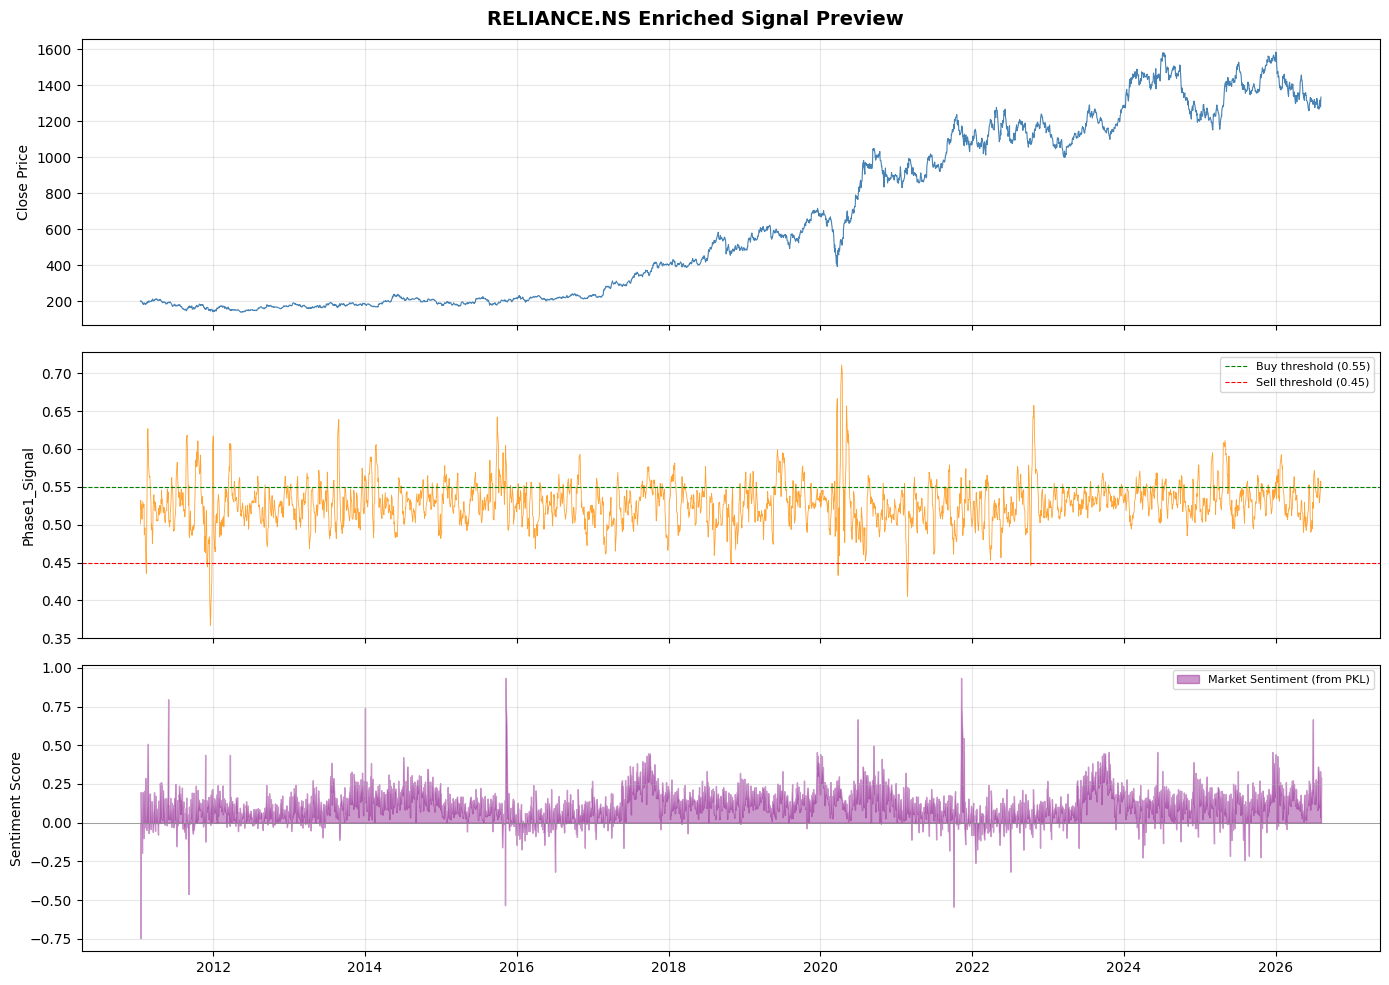

In [14]:
# CELL 7: VALIDATION & QUALITY CHECKS
import matplotlib.pyplot as plt

# Assertions
nan_count = int(df_enriched["Phase1_Signal"].isna().sum())
in_range  = bool(df_enriched["Phase1_Signal"].between(0.0, 1.0).all())
assert nan_count == 0,   "FAIL: NaN values in Phase1_Signal!"
assert in_range,         "FAIL: Signal values outside [0, 1]!"
assert len(df_enriched) > 1000, "FAIL: Too few rows stacked!"

print("VALIDATION REPORT")
print("=" * 50)
print("  Total Stacked Rows  :", len(df_enriched))
print("  Tickers available   :", list(df_enriched["Ticker"].unique()))
print("")
print(df_enriched.groupby("Ticker")["Phase1_Signal"].describe())
print("")
print("All validation checks passed!")

# Visualization preview for RELIANCE.NS
reliance_preview = df_enriched[df_enriched["Ticker"] == "RELIANCE.NS"]
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("RELIANCE.NS Enriched Signal Preview", fontsize=14, fontweight="bold")

axes[0].plot(reliance_preview.index, reliance_preview["Close_Price"], color="steelblue", lw=0.8)
axes[0].set_ylabel("Close Price")
axes[0].grid(alpha=0.3)

axes[1].plot(reliance_preview.index, reliance_preview["Phase1_Signal"], color="darkorange", lw=0.6, alpha=0.8)
axes[1].axhline(0.55, color="green", linestyle="--", lw=0.8, label="Buy threshold (0.55)")
axes[1].axhline(0.45, color="red",   linestyle="--", lw=0.8, label="Sell threshold (0.45)")
axes[1].set_ylabel("Phase1_Signal")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].fill_between(reliance_preview.index, reliance_preview["Sentiment"], color="purple", alpha=0.4,
                     label="Market Sentiment (from PKL)")
axes[2].axhline(0, color="gray", lw=0.5)
axes[2].set_ylabel("Sentiment Score")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# CELL 8: SAVE OUTPUT
os.makedirs(OUTPUT_DIR, exist_ok=True)

cols_to_save = [
    "Ticker", "Close_Price", "Volume",
    "Log_Ret", "Vol_20", "Vol_200", "Vol_Ratio",
    "Ret_1M", "Ret_3M", "Efficiency", "Vol_Shock",
    "Ret_Lag1", "Ret_Lag2", "Ret_Lag3", "Ret_Lag5", "Ret_Lag10", "Ret_Lag20",
    "Sentiment", "Phase1_Signal"
]
cols_to_save = [c for c in cols_to_save if c in df_enriched.columns]

df_enriched[cols_to_save].to_csv(OUTPUT_PATH, index=True, index_label="Date")
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)

print("Cell 8 done: Dataset saved!")
print("  Output path  :", os.path.abspath(OUTPUT_PATH))
print("  Total Rows   :", len(df_enriched))
print("  Columns saved:", len(cols_to_save), "->", cols_to_save)
print("  File size    : {:.2f} MB".format(size_mb))
print("")
print("Ready for Notebook 2.2 — RL Environment Definition!")


Cell 8 done: Dataset saved!
  Output path  : d:\Study\Projects\GenWealth\data\enriched_rl_data.csv
  Total Rows   : 15434
  Columns saved: 19 -> ['Ticker', 'Close_Price', 'Volume', 'Log_Ret', 'Vol_20', 'Vol_200', 'Vol_Ratio', 'Ret_1M', 'Ret_3M', 'Efficiency', 'Vol_Shock', 'Ret_Lag1', 'Ret_Lag2', 'Ret_Lag3', 'Ret_Lag5', 'Ret_Lag10', 'Ret_Lag20', 'Sentiment', 'Phase1_Signal']
  File size    : 5.54 MB

Ready for Notebook 2.2 — RL Environment Definition!
